In [1]:
import pandas as pd
import sqlite3
from sqlalchemy import create_engine

conn   = sqlite3.connect('olist_database.db')
engine = create_engine('sqlite:///olist_database.db')

print("Connected to olist_database.db ✓")

Connected to olist_database.db ✓


In [2]:
# Preview the two tables we'll be joining
orders_preview     = pd.read_sql("SELECT * FROM orders LIMIT 3", conn)
orderitems_preview = pd.read_sql("SELECT * FROM order_items LIMIT 3", conn)

print("=== orders columns ===")
print(orders_preview.columns.tolist())

print("\n=== order_items columns ===")
print(orderitems_preview.columns.tolist())

=== orders columns ===
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

=== order_items columns ===
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


In [3]:
monthly_revenue_query = '''
    SELECT
        STRFTIME('%Y-%m', o.order_purchase_timestamp)   AS revenue_month,
        COUNT(DISTINCT o.order_id)                       AS total_orders,
        ROUND(SUM(oi.price), 2)                          AS total_revenue,
        ROUND(AVG(oi.price), 2)                          AS avg_order_value
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE
        o.order_status = 'delivered'
        AND o.order_purchase_timestamp >= '2017-01-01'
        AND o.order_purchase_timestamp <  '2018-09-01'
    GROUP BY revenue_month
    ORDER BY revenue_month
'''

monthly_revenue = pd.read_sql_query(monthly_revenue_query, conn)
print(monthly_revenue.to_string(index=False))

revenue_month  total_orders  total_revenue  avg_order_value
      2017-01           750      111798.36           122.45
      2017-02          1653      234223.40           126.06
      2017-03          2546      359198.85           123.99
      2017-04          2303      340669.68           132.61
      2017-05          3546      489338.25           122.21
      2017-06          3135      421923.37           120.93
      2017-07          3872      481604.52           109.06
      2017-08          4193      554699.70           115.63
      2017-09          4150      607399.67           128.22
      2017-10          4478      648247.65           124.33
      2017-11          7289      987765.37           116.55
      2017-12          5513      726033.19           117.35
      2018-01          7069      924645.00           115.05
      2018-02          6555      826437.13           109.93
      2018-03          7003      953356.25           118.92
      2018-04          6798      973534.

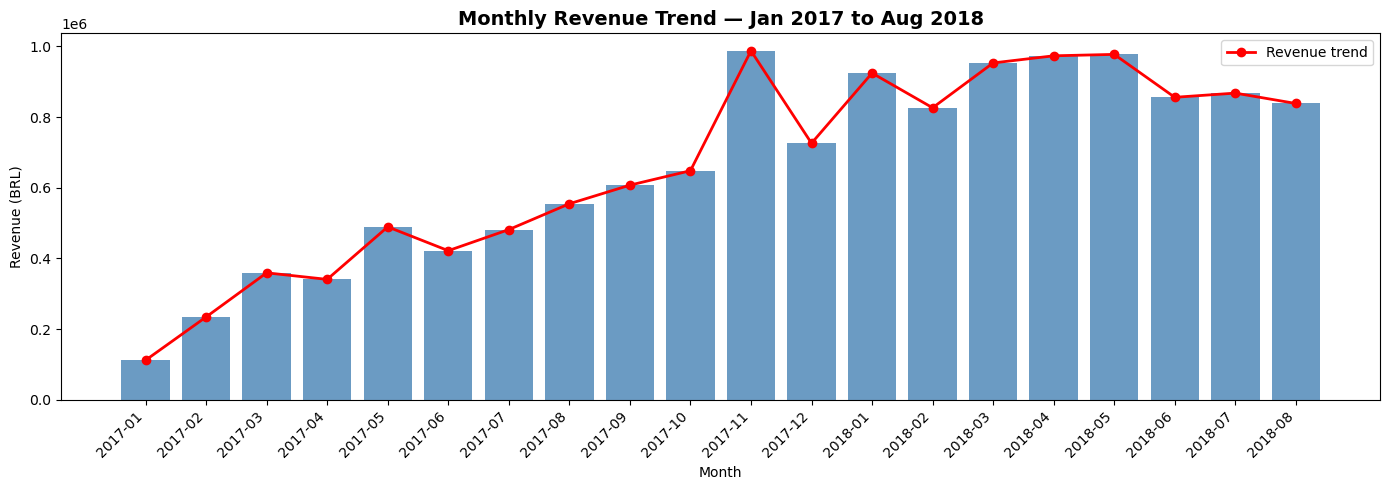

Peak month    : 2017-11
Peak revenue  : 987765.37
Lowest month  : 2017-01


In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(monthly_revenue['revenue_month'], 
       monthly_revenue['total_revenue'], 
       color='steelblue', alpha=0.8)

ax.plot(monthly_revenue['revenue_month'], 
        monthly_revenue['total_revenue'], 
        color='red', marker='o', linewidth=2, label='Revenue trend')

ax.set_title('Monthly Revenue Trend — Jan 2017 to Aug 2018', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (BRL)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

print("Peak month    :", monthly_revenue.loc[monthly_revenue['total_revenue'].idxmax(), 'revenue_month'])
print("Peak revenue  :", monthly_revenue['total_revenue'].max())
print("Lowest month  :", monthly_revenue.loc[monthly_revenue['total_revenue'].idxmin(), 'revenue_month'])

In [5]:
mom_query = '''
    WITH monthly AS (
        SELECT
            STRFTIME('%Y-%m', o.order_purchase_timestamp) AS revenue_month,
            ROUND(SUM(oi.price), 2)                        AS total_revenue
        FROM orders o
        JOIN order_items oi ON o.order_id = oi.order_id
        WHERE
            o.order_status = 'delivered'
            AND o.order_purchase_timestamp >= '2017-01-01'
            AND o.order_purchase_timestamp <  '2018-09-01'
        GROUP BY revenue_month
    )
    SELECT
        revenue_month,
        total_revenue,
        LAG(total_revenue) OVER (ORDER BY revenue_month)   AS prev_month_revenue,
        ROUND(
            (total_revenue - LAG(total_revenue) OVER (ORDER BY revenue_month))
            * 100.0
            / LAG(total_revenue) OVER (ORDER BY revenue_month),
        2)                                                  AS mom_growth_pct
    FROM monthly
    ORDER BY revenue_month
'''

mom_df = pd.read_sql_query(mom_query, conn)
print(mom_df.to_string(index=False))

revenue_month  total_revenue  prev_month_revenue  mom_growth_pct
      2017-01      111798.36                 NaN             NaN
      2017-02      234223.40           111798.36          109.51
      2017-03      359198.85           234223.40           53.36
      2017-04      340669.68           359198.85           -5.16
      2017-05      489338.25           340669.68           43.64
      2017-06      421923.37           489338.25          -13.78
      2017-07      481604.52           421923.37           14.15
      2017-08      554699.70           481604.52           15.18
      2017-09      607399.67           554699.70            9.50
      2017-10      648247.65           607399.67            6.73
      2017-11      987765.37           648247.65           52.37
      2017-12      726033.19           987765.37          -26.50
      2018-01      924645.00           726033.19           27.36
      2018-02      826437.13           924645.00          -10.62
      2018-03      953356

In [6]:
mom_query = '''
    WITH monthly AS (
        SELECT
            STRFTIME('%Y-%m', o.order_purchase_timestamp) AS revenue_month,
            ROUND(SUM(oi.price), 2)                        AS total_revenue
        FROM orders o
        JOIN order_items oi ON o.order_id = oi.order_id
        WHERE
            o.order_status = 'delivered'
            AND o.order_purchase_timestamp >= '2017-01-01'
            AND o.order_purchase_timestamp <  '2018-09-01'
        GROUP BY revenue_month
    )
    SELECT
        revenue_month,
        total_revenue,
        LAG(total_revenue) OVER (ORDER BY revenue_month)   AS prev_month_revenue,
        ROUND(
            (total_revenue - LAG(total_revenue) OVER (ORDER BY revenue_month))
            * 100.0
            / LAG(total_revenue) OVER (ORDER BY revenue_month),
        2)                                                  AS mom_growth_pct
    FROM monthly
    ORDER BY revenue_month
'''

mom_df = pd.read_sql_query(mom_query, conn)
print(mom_df.to_string(index=False))

revenue_month  total_revenue  prev_month_revenue  mom_growth_pct
      2017-01      111798.36                 NaN             NaN
      2017-02      234223.40           111798.36          109.51
      2017-03      359198.85           234223.40           53.36
      2017-04      340669.68           359198.85           -5.16
      2017-05      489338.25           340669.68           43.64
      2017-06      421923.37           489338.25          -13.78
      2017-07      481604.52           421923.37           14.15
      2017-08      554699.70           481604.52           15.18
      2017-09      607399.67           554699.70            9.50
      2017-10      648247.65           607399.67            6.73
      2017-11      987765.37           648247.65           52.37
      2017-12      726033.19           987765.37          -26.50
      2018-01      924645.00           726033.19           27.36
      2018-02      826437.13           924645.00          -10.62
      2018-03      953356

In [8]:
MoM % = (This Month Revenue - Last Month Revenue) / Last Month Revenue * 100

SyntaxError: invalid syntax (3937351564.py, line 1)